# HuffPost Category Classification — Experiment Analysis

**Date:** 2025-12-24

**Purpose:** This notebook analyzes the latest ML experiment results.

## Runtime Setup: Imports, Constants, and Reproducibility Seeds

This section sets up imports, defines workspace-relative constants, creates the output directory used to store generated PNGs, and configures random seeds for reproducibility.

It also includes a compatibility shim for the NumPy `np.object` FutureWarning noted in this workspace.

In [1]:
from __future__ import annotations

import json
import re
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Mapping, Optional

import numpy as np
import pandas as pd

# NumPy FutureWarning guard (workspace note)
if not hasattr(np, "object"):
    np.object = object  # type: ignore[attr-defined]

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from IPython.display import Markdown, display

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
 )

# Optional frameworks: only used for seeding (not required to run analysis)
try:
    import tensorflow as tf

    _HAS_TF = True
except Exception:
    tf = None  # type: ignore[assignment]
    _HAS_TF = False


def find_workspace_root(start: Path) -> Path:
    """Best-effort repo root discovery.

    Jupyter notebooks often run with CWD set to the notebook folder,
    so we walk upward until we find expected repo markers.
    """
    for p in [start, *start.parents]:
        if (p / "data" / "04-predictions").exists() and (p / "config" / "huffpost_category_text.json").exists():
            return p
    for p in [start, *start.parents]:
        if (p / "data").exists() and (p / "config").exists():
            return p
    return start


# -----------------------------
# Constants (workspace-relative)
# -----------------------------
CWD = Path.cwd()
WORKSPACE_ROOT = find_workspace_root(CWD)
PREDICTIONS_ROOT = WORKSPACE_ROOT / "data" / "04-predictions"
CONFIG_PATH = WORKSPACE_ROOT / "config" / "huffpost_category_text.json"

NOTEBOOK_NAME = "analysis_2025-12-24_11-18"
OUTPUT_DIR = WORKSPACE_ROOT / "notebooks" / NOTEBOOK_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DPI = 160
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
if _HAS_TF:
    tf.random.set_seed(RANDOM_SEED)

print("Notebook runtime UTC:", datetime.utcnow().isoformat() + "Z")
print("CWD:", CWD)
print("Workspace root:", WORKSPACE_ROOT)
print("Output directory:", OUTPUT_DIR)
print("Predictions root:", PREDICTIONS_ROOT)
print("TensorFlow available:", _HAS_TF)


C:\Users\dave\AppData\Local\Temp\ipykernel_164088\804771310.py:14: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Notebook runtime UTC: 2025-12-29T14:34:45.010621Z
CWD: d:\repos\ml_classification_example\notebooks
Workspace root: d:\repos\ml_classification_example
Output directory: d:\repos\ml_classification_example\notebooks\analysis_2025-12-24_11-18
Predictions root: d:\repos\ml_classification_example\data\04-predictions
TensorFlow available: True


C:\Users\dave\AppData\Local\Temp\ipykernel_164088\804771310.py:73: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  print("Notebook runtime UTC:", datetime.utcnow().isoformat() + "Z")


## Workspace Discovery: Locate Experiment Directories and Latest Runs

This section scans the workspace for experiment outputs under `data/04-predictions/` and selects the latest run per experiment (using timestamped folders when available). We build a structured index of experiments and their artifact paths so downstream analysis is consistent and reproducible.

In [2]:
TIMESTAMP_DIR_RE = re.compile(r"^\d{8}T\d{6}Z$")


@dataclass(frozen=True)
class RunArtifacts:
    dataset: str
    experiment: str
    run_id: str
    run_dir: Path
    metrics_test_path: Optional[Path]
    metrics_valid_path: Optional[Path]
    predictions_test_path: Optional[Path]
    predictions_valid_path: Optional[Path]


def _safe_read_json(path: Path) -> Dict[str, Any]:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def _parse_run_id(run_dir: Path) -> str:
    # Prefer the folder name if it matches the timestamp convention.
    name = run_dir.name
    if TIMESTAMP_DIR_RE.match(name):
        return name
    return name


def _find_latest_run_dir(experiment_dir: Path) -> Optional[Path]:
    if not experiment_dir.exists() or not experiment_dir.is_dir():
        return None

    run_dirs = [p for p in experiment_dir.iterdir() if p.is_dir()]
    if not run_dirs:
        return None

    # Prefer timestamp-like directories, sorted lexicographically == chronological.
    ts_dirs = [p for p in run_dirs if TIMESTAMP_DIR_RE.match(p.name)]
    if ts_dirs:
        return sorted(ts_dirs, key=lambda p: p.name)[-1]

    # Fallback: latest modification time.
    return sorted(run_dirs, key=lambda p: p.stat().st_mtime)[-1]


def discover_latest_runs(predictions_root: Path) -> List[RunArtifacts]:
    """Discover latest run per experiment under data/04-predictions."""

    runs: List[RunArtifacts] = []

    if not predictions_root.exists():
        print(f"Predictions root not found: {predictions_root}")
        print("If you ran from a notebook subfolder, re-run Cell 3 to auto-detect WORKSPACE_ROOT.")
        return []

    # Expected layout: data/04-predictions/<dataset>/<experiment>/<run_id>/...
    for dataset_dir in sorted([p for p in predictions_root.iterdir() if p.is_dir()]):
        for exp_dir in sorted([p for p in dataset_dir.iterdir() if p.is_dir()]):
            latest = _find_latest_run_dir(exp_dir)
            if latest is None:
                continue

            def maybe(path: Path) -> Optional[Path]:
                return path if path.exists() else None

            runs.append(
                RunArtifacts(
                    dataset=str(dataset_dir.name),
                    experiment=str(exp_dir.name),
                    run_id=_parse_run_id(latest),
                    run_dir=latest,
                    metrics_test_path=maybe(latest / "metrics_test.json"),
                    metrics_valid_path=maybe(latest / "metrics_valid.json"),
                    predictions_test_path=maybe(latest / "predictions_test.csv"),
                    predictions_valid_path=maybe(latest / "predictions_valid.csv"),
                )
            )

    # Stable ordering: dataset then experiment
    runs = sorted(runs, key=lambda r: (r.dataset, r.experiment))
    return runs


latest_runs = discover_latest_runs(PREDICTIONS_ROOT)
print("Discovered latest runs:")
for r in latest_runs:
    print(f"- {r.dataset}/{r.experiment}/{r.run_id}")


Discovered latest runs:
- huffpost/distilbert_frozen/20251222T190244Z
- huffpost/distilbert_two_phase/20251223T165758Z
- huffpost/distilbert_unfrozen/20251223T010101Z
- huffpost/tfidf_dense/20251222T184926Z
- huffpost/tfidf_logreg/20251222T183959Z


## Config Intake: Read Dataset/Experiment Settings

This section loads project configuration (splits, seeds, and visualization palette) from `config/huffpost_category_text.json`.

When settings are missing, we fall back to sensible defaults and log what was inferred.

In [3]:
cfg: Dict[str, Any] = {}
if CONFIG_PATH.exists():
    cfg = _safe_read_json(CONFIG_PATH)

split_cfg = cfg.get("split", {}) if isinstance(cfg, Mapping) else {}
training_cfg = cfg.get("training", {}) if isinstance(cfg, Mapping) else {}
vis_cfg = cfg.get("visualization", {}) if isinstance(cfg, Mapping) else {}

VALID_RATIO = float(split_cfg.get("valid_ratio", 0.1))
TEST_RATIO = float(split_cfg.get("test_ratio", 0.1))
SPLIT_STRATEGY = str(split_cfg.get("strategy", "stratified"))
PROJECT_NAME = str(cfg.get("project", {}).get("name", "huffpost-category-classification"))

COLOR_PALETTE: List[str] = list(vis_cfg.get("color_palette", ["#c6d4e1", "#1f4f75"]))
if len(COLOR_PALETTE) < 2:
    COLOR_PALETTE = ["#c6d4e1", "#1f4f75"]

PRIMARY_METRIC = "macro_f1"  # best default for potentially imbalanced multiclass

cm_cmap = LinearSegmentedColormap.from_list(
    "custom_cm",
    [COLOR_PALETTE[0], COLOR_PALETTE[min(5, len(COLOR_PALETTE) - 1)]],
)

print("Project:", PROJECT_NAME)
print("Split strategy:", SPLIT_STRATEGY)
print("Valid ratio:", VALID_RATIO)
print("Test ratio:", TEST_RATIO)
print("Primary metric:", PRIMARY_METRIC)
print("Palette size:", len(COLOR_PALETTE))


Project: huffpost-category-classification
Split strategy: stratified
Valid ratio: 0.1
Test ratio: 0.1
Primary metric: macro_f1
Palette size: 9


## Artifacts Loader: Training Logs, Metrics JSON, Predictions, and Labels

This section defines robust loader utilities that can ingest common run artifacts:

- `metrics_*.json`
- `predictions_*.csv`
- optional training history logs (Keras History JSON/CSV)

These loaders are schema-tolerant and designed to keep the notebook runnable even if some artifacts are missing.

In [4]:
def find_training_log(run_dir: Path) -> Optional[Path]:
    """Return a path to a training log if present (best-effort)."""

    candidates = [
        run_dir / "history.json",
        run_dir / "history.csv",
        run_dir / "training_log.csv",
        run_dir / "train_log.csv",
    ]
    for p in candidates:
        if p.exists():
            return p

    # Heuristic: any CSV/JSON with "loss" in name
    for p in sorted(run_dir.glob("*.json")) + sorted(run_dir.glob("*.csv")):
        if "loss" in p.name.lower() or "history" in p.name.lower():
            return p

    return None


def load_metrics(metrics_path: Path) -> Dict[str, Any]:
    """Load metrics JSON emitted by src/pipelines/evaluate/classification.py."""

    payload = _safe_read_json(metrics_path)
    # Normalize keys (some pipelines may use different naming)
    metrics = payload.get("metrics", {}) if isinstance(payload, Mapping) else {}
    extra = payload.get("extra", {}) if isinstance(payload, Mapping) else {}
    return {
        "generated_at_utc": payload.get("generated_at_utc"),
        "metrics": dict(metrics) if isinstance(metrics, Mapping) else {},
        "extra": dict(extra) if isinstance(extra, Mapping) else {},
    }


def load_predictions(pred_path: Path) -> pd.DataFrame:
    """Load predictions CSV and normalize expected columns."""

    df = pd.read_csv(pred_path)

    # Expected columns: y_true, y_pred (+ optional y_true_label, y_pred_label)
    required = {"y_true", "y_pred"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Predictions file missing columns {missing}: {pred_path}")

    return df


def load_history(history_path: Path) -> Dict[str, List[float]]:
    """Load training history from JSON or CSV into a dict of lists.

    JSON format supports Keras History-like {'loss':[...], 'val_loss':[...], ...}.
    CSV format supports a header with columns like epoch, loss, val_loss, accuracy, val_accuracy.
    """

    if history_path.suffix.lower() == ".json":
        payload = _safe_read_json(history_path)
        if isinstance(payload, Mapping):
            out: Dict[str, List[float]] = {}
            for k, v in payload.items():
                if isinstance(v, list) and v and all(isinstance(x, (int, float)) for x in v):
                    out[str(k)] = [float(x) for x in v]
            return out
        raise ValueError(f"Unexpected JSON history format: {history_path}")

    if history_path.suffix.lower() == ".csv":
        df = pd.read_csv(history_path)
        out = {}
        for col in df.columns:
            if col.lower() in {"epoch"}:
                continue
            series = df[col]
            if pd.api.types.is_numeric_dtype(series):
                out[str(col)] = [float(x) for x in series.fillna(np.nan).tolist()]
        return out

    raise ValueError(f"Unsupported history format: {history_path}")


def infer_primary_metric_key(history: Mapping[str, Any]) -> str:
    """Infer a reasonable metric key for plotting."""

    candidates = ["accuracy", "sparse_categorical_accuracy", "macro_f1", "f1"]
    for cand in candidates:
        if cand in history:
            return cand
    raise ValueError(f"Could not infer metric key. Available keys: {list(history.keys())}")


def plot_training_curves(
    history: Mapping[str, List[float]],
    *,
    experiment_label: str,
    output_dir: Path,
    run_id: str,
    metric_key: Optional[str] = None,
) -> List[Path]:
    """Plot loss and a primary metric from a history dict. Saves PNGs and returns paths."""

    saved: List[Path] = []

    if metric_key is None:
        metric_key = infer_primary_metric_key(history)

    epochs = range(1, len(history.get("loss", [])) + 1)

    # --- Loss ---
    if "loss" in history:
        plt.figure(figsize=(7, 4))
        plt.plot(list(epochs), history["loss"], label="Train Loss")
        if "val_loss" in history:
            plt.plot(list(epochs), history["val_loss"], linestyle="--", label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"{experiment_label} — Training vs Validation Loss")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        out = output_dir / f"{experiment_label}_{run_id}_loss.png"
        plt.savefig(out, dpi=FIG_DPI)
        saved.append(out)
        plt.show()

    # --- Metric ---
    if metric_key in history:
        plt.figure(figsize=(7, 4))
        plt.plot(list(epochs), history[metric_key], label=f"Train {metric_key}")
        val_key = f"val_{metric_key}"
        if val_key in history:
            plt.plot(list(epochs), history[val_key], linestyle="--", label=f"Val {metric_key}")
        plt.xlabel("Epoch")
        plt.ylabel(metric_key)
        plt.title(f"{experiment_label} — Training vs Validation {metric_key}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        out = output_dir / f"{experiment_label}_{run_id}_metric_{metric_key}.png"
        plt.savefig(out, dpi=FIG_DPI)
        saved.append(out)
        plt.show()

    return saved


def plot_confusion_matrix(
    cm: np.ndarray,
    class_names: List[str],
    *,
    title: str,
    output_path: Path,
    normalize: bool = True,
) -> None:
    """Plot and save a confusion matrix (optionally row-normalized)."""

    cm_arr = np.asarray(cm)

    if normalize:
        row_sums = cm_arr.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        cm_plot = cm_arr.astype(float) / row_sums
    else:
        cm_plot = cm_arr

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm_plot, aspect="auto", cmap=cm_cmap)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=90)
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    # Small annotations (kept readable)
    thresh = float(np.nanmax(cm_plot)) / 2.0 if cm_plot.size else 0.0
    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            value = cm_plot[i, j]
            txt = f"{value:.2f}" if normalize else str(int(value))
            ax.text(
                j,
                i,
                txt,
                ha="center",
                va="center",
                fontsize=6,
                color="white" if value > thresh else "black",
            )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(output_path, dpi=FIG_DPI)
    plt.show()


## A.1 — Dataset & Evaluation Strategy

**Validation split:** The validation split is used during development for model selection (e.g., early stopping, hyperparameter comparisons, schedule tuning). It provides a proxy for generalization without consuming the final held-out test set.

**Test set:** The test set is kept separate and used only once a model choice is finalized, so reported metrics represent an unbiased estimate of real-world performance.

**Metrics:** For multiclass text classification, accuracy is intuitive but can mask poor performance on minority classes. Macro-F1 is often a better primary metric when classes are imbalanced because it weights each class equally.

The $F_1$ score is:

$$F_1 = 2\frac{PR}{P+R}$$

where $P$ is precision and $R$ is recall.

In [5]:
print("Dataset:", cfg.get("dataset", {}).get("name", "HuffPost"))
print("Split strategy:", SPLIT_STRATEGY)
print("Validation ratio:", VALID_RATIO)
print("Test ratio:", TEST_RATIO)

print("\nDiscovered experiments (latest runs):")
for r in latest_runs:
    print(f"- {r.dataset}/{r.experiment}/{r.run_id}")


Dataset: HuffPost News Category Dataset
Split strategy: stratified
Validation ratio: 0.1
Test ratio: 0.1

Discovered experiments (latest runs):
- huffpost/distilbert_frozen/20251222T190244Z
- huffpost/distilbert_two_phase/20251223T165758Z
- huffpost/distilbert_unfrozen/20251223T010101Z
- huffpost/tfidf_dense/20251222T184926Z
- huffpost/tfidf_logreg/20251222T183959Z


## A.2 — Training & Validation Analysis

For each experiment’s latest run, we try to load per-epoch training logs (loss and accuracy curves). These curves help diagnose convergence and generalization:

- Diverging train/val loss can indicate overfitting.
- Flat accuracy curves can indicate underfitting or optimization issues.

If a run does not include a saved training history, we note it explicitly (the current pipelines primarily persist final metrics/predictions).

In [6]:
saved_training_plots: List[Path] = []

for r in latest_runs:
    exp_label = r.experiment
    run_id = r.run_id
    run_dir = r.run_dir

    display(Markdown(f"### {r.dataset}/{exp_label}/{run_id} — Training & validation curves"))

    history_path = find_training_log(run_dir)

    if history_path is None:
        display(Markdown("_No per-epoch training log found in the run directory; skipping curves._"))
        print("Note: current pipelines persist final metrics/predictions, but not training curves.")
        continue

    try:
        history = load_history(history_path)
    except Exception as exc:
        display(Markdown(f"_Failed to load training log; skipping curves._"))
        print("Training log path:", history_path)
        print("Error:", exc)
        continue

    if not history:
        display(Markdown("_Training log loaded but no numeric series were detected; skipping curves._"))
        print("Training log path:", history_path)
        continue

    metric_key = None
    try:
        metric_key = infer_primary_metric_key(history)
    except Exception:
        metric_key = None

    display(Markdown("**Plot:** Training/validation curves (if available)"))
    plots = plot_training_curves(
        history,
        experiment_label=exp_label,
        output_dir=OUTPUT_DIR,
        run_id=run_id,
        metric_key=metric_key,
    )

    saved_training_plots.extend(plots)

print("\nSaved training/validation plots:")
for p in saved_training_plots:
    print("-", p.as_posix())


### huffpost/distilbert_frozen/20251222T190244Z — Training & validation curves

_No per-epoch training log found in the run directory; skipping curves._

Note: current pipelines persist final metrics/predictions, but not training curves.


### huffpost/distilbert_two_phase/20251223T165758Z — Training & validation curves

_No per-epoch training log found in the run directory; skipping curves._

...

_No per-epoch training log found in the run directory; skipping curves._

Note: current pipelines persist final metrics/predictions, but not training curves.


### huffpost/tfidf_logreg/20251222T183959Z — Training & validation curves

_No per-epoch training log found in the run directory; skipping curves._

Note: current pipelines persist final metrics/predictions, but not training curves.

Saved training/validation plots:


## A.3 — Test Set Evaluation

For each experiment’s latest run, we evaluate test-set performance using saved predictions. We compute:

- Confusion matrix (row-normalized), saved as PNG
- Per-class precision/recall/F1/support table
- Aggregate F1 scores (macro/micro/weighted) and accuracy

These outputs make it easy to spot which classes are consistently confused and whether gains are broad-based or concentrated in frequent categories.

### huffpost/distilbert_frozen/20251222T190244Z — Test evaluation

**Summary metrics (test):**

Accuracy     : 0.5650
Macro F1     : 0.3941
Micro F1     : 0.5650
Weighted F1  : 0.5296


**Plot:** Normalized confusion matrix (test)

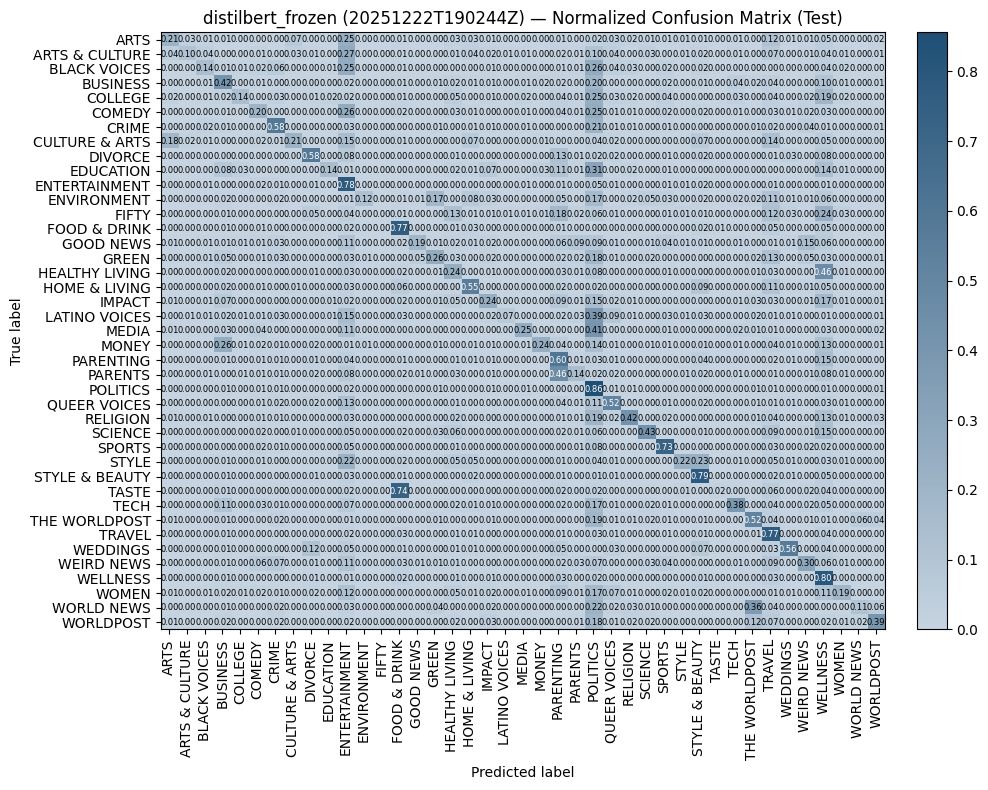

**Table:** Per-class precision/recall/F1/support (preview)

,label,precision,recall,f1-score,support
0,ARTS,0.310680,0.211921,0.251969,151.0
1,ARTS & CULTURE,0.466667,0.104478,0.170732,134.0
10,ENTERTAINMENT,0.553239,0.776463,0.646114,1606.0
11,ENVIRONMENT,0.695652,0.121212,0.206452,132.0
12,FIFTY,0.000000,0.000000,0.000000,140.0
13,FOOD & DRINK,0.575211,0.767255,0.657497,623.0
14,GOOD NEWS,0.456140,0.185714,0.263959,140.0
15,GREEN,0.413174,0.263359,0.321678,262.0
16,HEALTHY LIVING,0.416880,0.243647,0.307547,669.0
17,HOME & LIVING,0.627027,0.552381,0.587342,420.0


### huffpost/distilbert_two_phase/20251223T165758Z — Test evaluation

**Summary metrics (test):**

Accuracy     : 0.7124
Macro F1     : 0.6183
Micro F1     : 0.7124
Weighted F1  : 0.7066


**Plot:** Normalized confusion matrix (test)

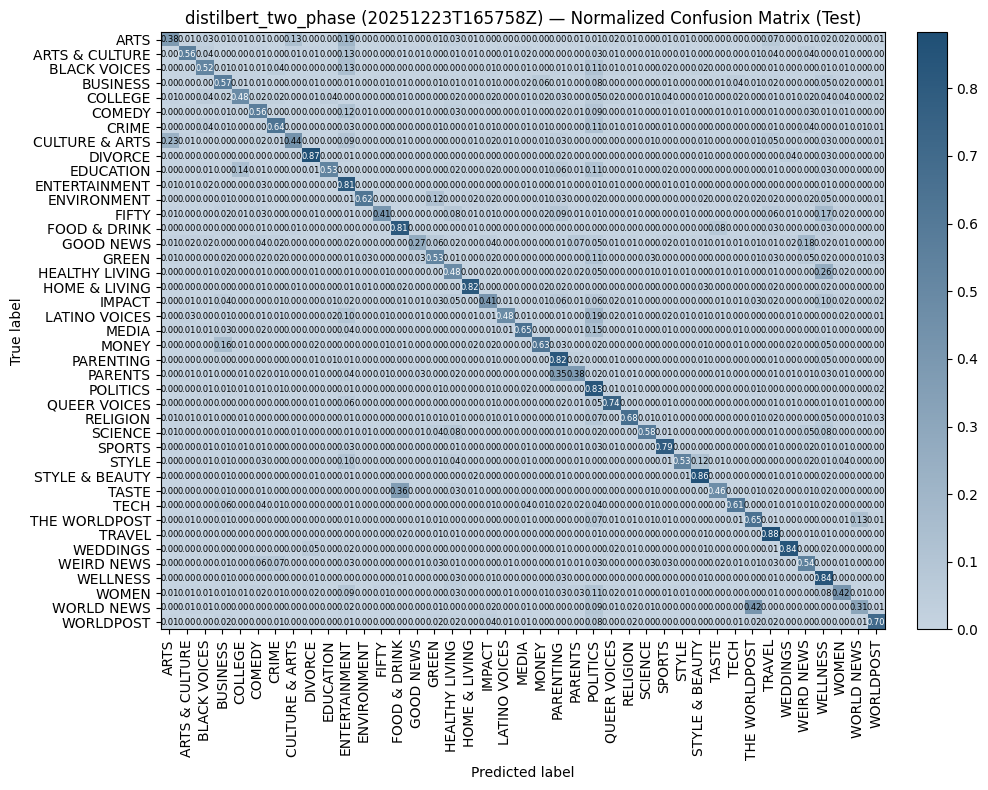

**Table:** Per-class precision/recall/F1/support (preview)

,label,precision,recall,f1-score,support
0,ARTS,0.428571,0.377483,0.401408,151.0
1,ARTS & CULTURE,0.585938,0.559701,0.572519,134.0
10,ENTERTAINMENT,0.740319,0.809465,0.773349,1606.0
11,ENVIRONMENT,0.706897,0.621212,0.661290,132.0
12,FIFTY,0.626374,0.407143,0.493506,140.0
13,FOOD & DRINK,0.768645,0.810594,0.789062,623.0
14,GOOD NEWS,0.457831,0.271429,0.340807,140.0
15,GREEN,0.545098,0.530534,0.537718,262.0
16,HEALTHY LIVING,0.593346,0.479821,0.530579,669.0
17,HOME & LIVING,0.851485,0.819048,0.834951,420.0


### huffpost/distilbert_unfrozen/20251223T010101Z — Test evaluation

**Summary metrics (test):**

Accuracy     : 0.7069
Macro F1     : 0.6048
Micro F1     : 0.7069
Weighted F1  : 0.6992


**Plot:** Normalized confusion matrix (test)

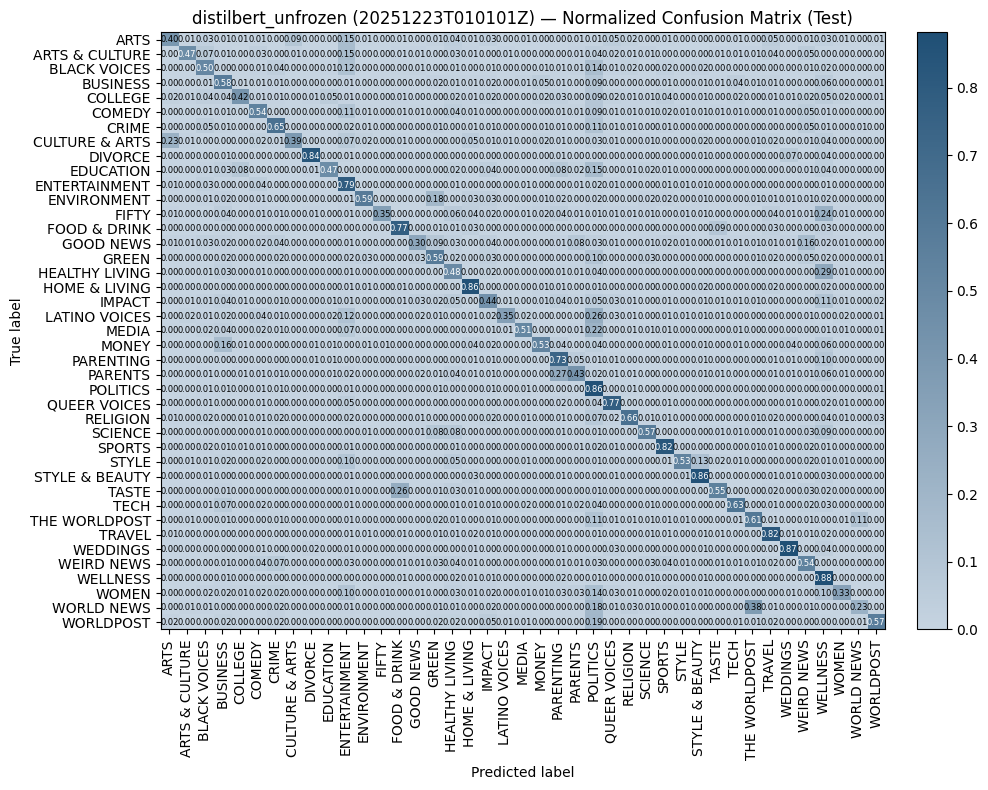

**Table:** Per-class precision/recall/F1/support (preview)

,label,precision,recall,f1-score,support
0,ARTS,0.461538,0.397351,0.427046,151.0
1,ARTS & CULTURE,0.656250,0.470149,0.547826,134.0
10,ENTERTAINMENT,0.753709,0.790785,0.771802,1606.0
11,ENVIRONMENT,0.604651,0.590909,0.597701,132.0
12,FIFTY,0.777778,0.350000,0.482759,140.0
13,FOOD & DRINK,0.807370,0.773676,0.790164,623.0
14,GOOD NEWS,0.420000,0.300000,0.350000,140.0
15,GREEN,0.500000,0.591603,0.541958,262.0
16,HEALTHY LIVING,0.569420,0.484305,0.523425,669.0
17,HOME & LIVING,0.704280,0.861905,0.775161,420.0


### huffpost/tfidf_dense/20251222T184926Z — Test evaluation

**Summary metrics (test):**

Accuracy     : 0.5221
Macro F1     : 0.3370
Micro F1     : 0.5221
Weighted F1  : 0.4866


**Plot:** Normalized confusion matrix (test)

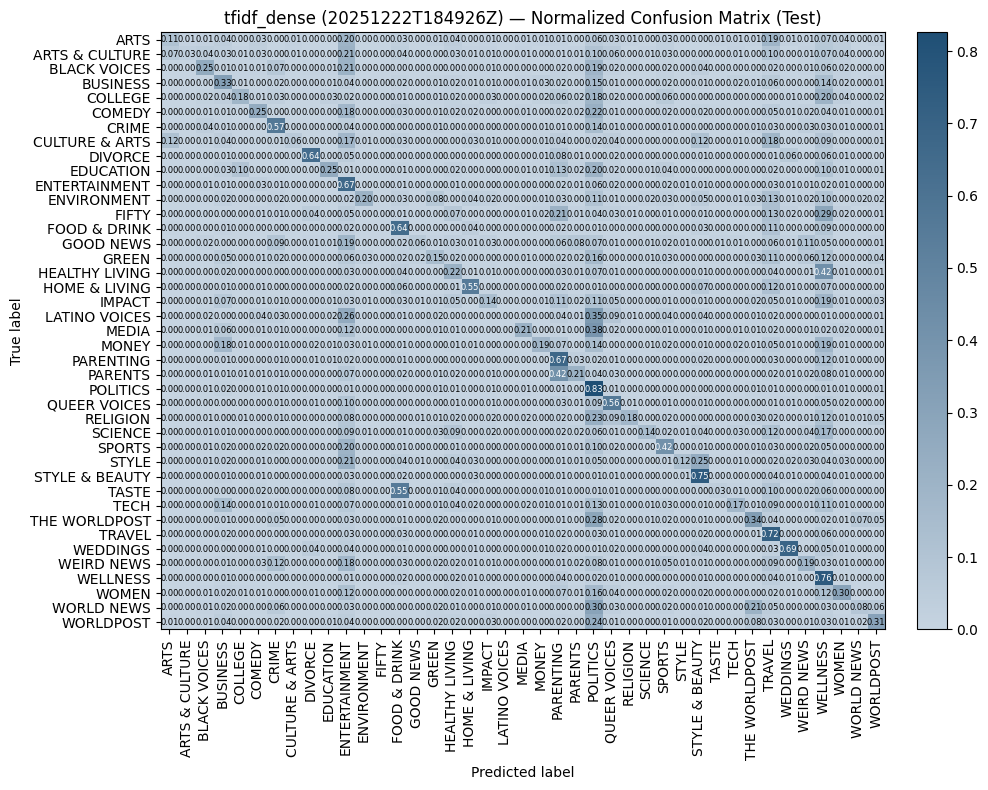

**Table:** Per-class precision/recall/F1/support (preview)

,label,precision,recall,f1-score,support
0,ARTS,0.265625,0.112583,0.158140,151.0
1,ARTS & CULTURE,0.444444,0.029851,0.055944,134.0
10,ENTERTAINMENT,0.498150,0.670610,0.571656,1606.0
11,ENVIRONMENT,0.457627,0.204545,0.282723,132.0
12,FIFTY,0.000000,0.000000,0.000000,140.0
13,FOOD & DRINK,0.499377,0.643660,0.562412,623.0
14,GOOD NEWS,0.281250,0.064286,0.104651,140.0
15,GREEN,0.251656,0.145038,0.184019,262.0
16,HEALTHY LIVING,0.368020,0.216741,0.272813,669.0
17,HOME & LIVING,0.632153,0.552381,0.589581,420.0


### huffpost/tfidf_logreg/20251222T183959Z — Test evaluation

**Summary metrics (test):**

Accuracy     : 0.6221
Macro F1     : 0.4909
Micro F1     : 0.6221
Weighted F1  : 0.6045


**Plot:** Normalized confusion matrix (test)

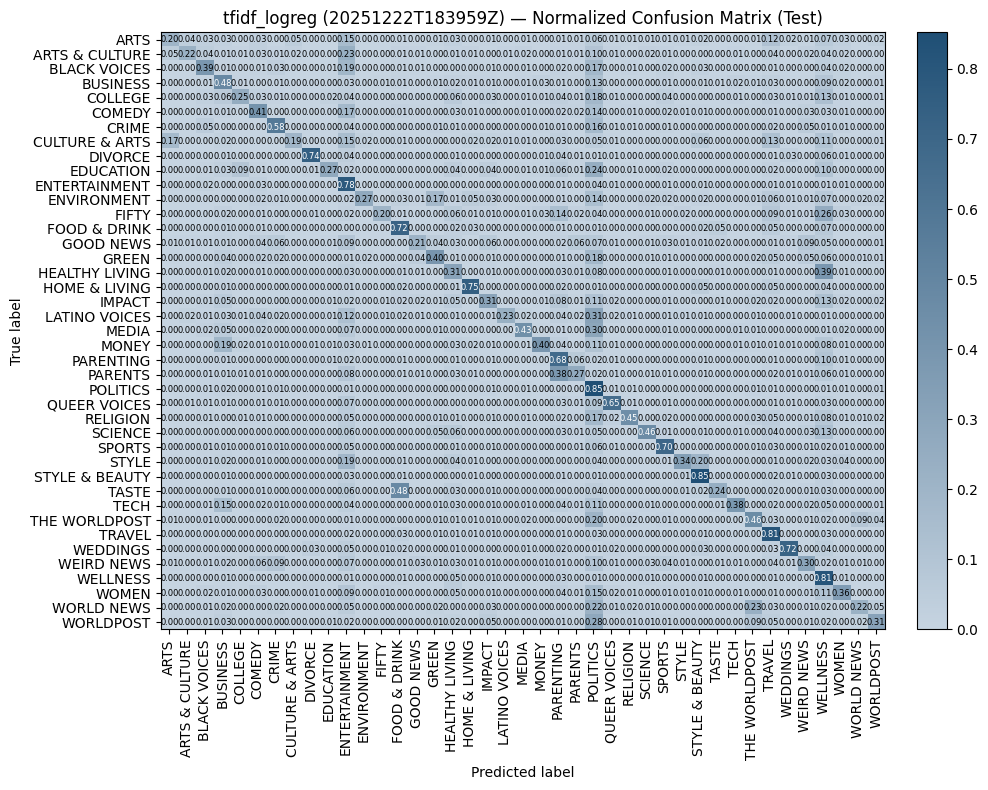

**Table:** Per-class precision/recall/F1/support (preview)

,label,precision,recall,f1-score,support
0,ARTS,0.365854,0.198675,0.257511,151.0
1,ARTS & CULTURE,0.517241,0.223881,0.312500,134.0
10,ENTERTAINMENT,0.621836,0.780199,0.692074,1606.0
11,ENVIRONMENT,0.679245,0.272727,0.389189,132.0
12,FIFTY,0.518519,0.200000,0.288660,140.0
13,FOOD & DRINK,0.649709,0.717496,0.681922,623.0
14,GOOD NEWS,0.371795,0.207143,0.266055,140.0
15,GREEN,0.492891,0.396947,0.439746,262.0
16,HEALTHY LIVING,0.387454,0.313901,0.346821,669.0
17,HOME & LIVING,0.795455,0.750000,0.772059,420.0



Saved confusion matrices:
- d:/repos/ml_classification_example/notebooks/analysis_2025-12-24_11-18/distilbert_frozen_20251222T190244Z_confusion_matrix_normalized.png
- d:/repos/ml_classification_example/notebooks/analysis_2025-12-24_11-18/distilbert_two_phase_20251223T165758Z_confusion_matrix_normalized.png
- d:/repos/ml_classification_example/notebooks/analysis_2025-12-24_11-18/distilbert_unfrozen_20251223T010101Z_confusion_matrix_normalized.png
- d:/repos/ml_classification_example/notebooks/analysis_2025-12-24_11-18/tfidf_dense_20251222T184926Z_confusion_matrix_normalized.png
- d:/repos/ml_classification_example/notebooks/analysis_2025-12-24_11-18/tfidf_logreg_20251222T183959Z_confusion_matrix_normalized.png


In [7]:
def compute_test_tables(df_pred: pd.DataFrame) -> Dict[str, Any]:
    """Compute confusion matrix and classification report tables from predictions."""

    y_true = df_pred["y_true"].to_numpy()
    y_pred = df_pred["y_pred"].to_numpy()

    # Class labels for consistent confusion-matrix axes
    classes = sorted(set(y_true.tolist()) | set(y_pred.tolist()))

    cm = confusion_matrix(y_true, y_pred, labels=classes)

    # Aggregate metrics
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    # Per-class metrics
    report = classification_report(
        y_true,
        y_pred,
        labels=classes,
        output_dict=True,
        zero_division=0,
    )

    report_df = (
        pd.DataFrame(report)
        .transpose()
        .rename_axis("label")
        .reset_index()
        .sort_values(by="label", key=lambda s: s.astype(str))
    )

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "classes": classes,
        "confusion_matrix": cm,
        "accuracy": float(acc),
        "f1_macro": float(f1_macro),
        "f1_micro": float(f1_micro),
        "f1_weighted": float(f1_weighted),
        "report_df": report_df,
    }


saved_cm_paths: List[Path] = []
per_experiment_summaries: List[Dict[str, Any]] = []

for r in latest_runs:
    if r.predictions_test_path is None:
        display(Markdown(f"### {r.dataset}/{r.experiment}/{r.run_id} — Test evaluation"))
        display(Markdown("_No predictions_test.csv found; skipping test evaluation._"))
        continue

    display(Markdown(f"### {r.dataset}/{r.experiment}/{r.run_id} — Test evaluation"))

    df_pred = load_predictions(r.predictions_test_path)

    tables = compute_test_tables(df_pred)

    # Build class names (prefer provided labels if available)
    if "y_true_label" in df_pred.columns and "y_pred_label" in df_pred.columns:
        # Map class index -> label using the most frequent label seen for that index
        mapping = (
            df_pred[["y_true", "y_true_label"]]
            .dropna()
            .groupby("y_true")["y_true_label"]
            .agg(lambda s: s.value_counts().index[0])
            .to_dict()
        )
        class_names = [str(mapping.get(c, c)) for c in tables["classes"]]
    else:
        class_names = [str(c) for c in tables["classes"]]

    display(Markdown("**Summary metrics (test):**"))
    print(f"Accuracy     : {tables['accuracy']:.4f}")
    print(f"Macro F1     : {tables['f1_macro']:.4f}")
    print(f"Micro F1     : {tables['f1_micro']:.4f}")
    print(f"Weighted F1  : {tables['f1_weighted']:.4f}")

    # Save + show confusion matrix
    display(Markdown("**Plot:** Normalized confusion matrix (test)"))
    cm_out = OUTPUT_DIR / f"{r.experiment}_{r.run_id}_confusion_matrix_normalized.png"
    plot_confusion_matrix(
        tables["confusion_matrix"],
        class_names=class_names,
        title=f"{r.experiment} ({r.run_id}) — Normalized Confusion Matrix (Test)",
        output_path=cm_out,
        normalize=True,
    )
    saved_cm_paths.append(cm_out)

    # Per-class report
    display(Markdown("**Table:** Per-class precision/recall/F1/support (preview)"))
    report_df = tables["report_df"].copy()
    # Replace numeric labels with names where possible
    label_to_name = {str(c): n for c, n in zip(tables["classes"], class_names)}
    report_df["label"] = report_df["label"].astype(str).map(lambda x: label_to_name.get(x, x))

    display(report_df.head(10))

    # Persist per-experiment report
    report_out = OUTPUT_DIR / f"{r.experiment}_{r.run_id}_per_class_report.csv"
    report_df.to_csv(report_out, index=False)

    per_experiment_summaries.append(
        {
            "dataset": r.dataset,
            "experiment": r.experiment,
            "run_id": r.run_id,
            "accuracy": tables["accuracy"],
            "macro_f1": tables["f1_macro"],
            "micro_f1": tables["f1_micro"],
            "weighted_f1": tables["f1_weighted"],
            "predictions_path": r.predictions_test_path.as_posix(),
            "metrics_path": r.metrics_test_path.as_posix() if r.metrics_test_path else None,
        }
    )

print("\nSaved confusion matrices:")
for p in saved_cm_paths:
    print("-", p.as_posix())


## Experiment Comparison: Consolidated Metrics Table + Best Model Selection

This section aggregates the latest test metrics across experiments and selects the best-performing model.

We rank by **macro-F1** (primary) and use **accuracy** as a tie-breaker.

In [8]:
comparison_rows: List[Dict[str, Any]] = []

for r in latest_runs:
    if r.metrics_test_path and r.metrics_test_path.exists():
        m = load_metrics(r.metrics_test_path)
        metrics = m.get("metrics", {})
        comparison_rows.append(
            {
                "dataset": r.dataset,
                "experiment": r.experiment,
                "run_id": r.run_id,
                "accuracy": float(metrics.get("accuracy", np.nan)),
                "macro_f1": float(metrics.get("macro_f1", np.nan)),
                "metrics_test_path": r.metrics_test_path.as_posix(),
                "run_dir": r.run_dir.as_posix(),
            }
        )
    else:
        # Fallback to computed metrics from predictions if metrics JSON is missing.
        match = next(
            (
                s
                for s in per_experiment_summaries
                if s["dataset"] == r.dataset and s["experiment"] == r.experiment and s["run_id"] == r.run_id
            ),
            None,
        )
        if match is not None:
            comparison_rows.append(
                {
                    "dataset": r.dataset,
                    "experiment": r.experiment,
                    "run_id": r.run_id,
                    "accuracy": float(match.get("accuracy", np.nan)),
                    "macro_f1": float(match.get("macro_f1", np.nan)),
                    "metrics_test_path": None,
                    "run_dir": r.run_dir.as_posix(),
                }
            )

comparison_df = pd.DataFrame(comparison_rows)

if not comparison_df.empty:
    comparison_df = comparison_df.sort_values(
        by=["macro_f1", "accuracy"],
        ascending=[False, False],
        na_position="last",
    ).reset_index(drop=True)

comparison_df


,dataset,experiment,run_id,accuracy,macro_f1,metrics_test_path,run_dir
0,huffpost,distilbert_two_phase,20251223T165758Z,0.712387,0.618282,d:/repos/ml_classification_example/data/04-pre...,d:/repos/ml_classification_example/data/04-pre...
1,huffpost,distilbert_unfrozen,20251223T010101Z,0.706860,0.604783,d:/repos/ml_classification_example/data/04-pre...,d:/repos/ml_classification_example/data/04-pre...
2,huffpost,tfidf_logreg,20251222T183959Z,0.622125,0.490883,d:/repos/ml_classification_example/data/04-pre...,d:/repos/ml_classification_example/data/04-pre...
3,huffpost,distilbert_frozen,20251222T190244Z,0.565020,0.394110,d:/repos/ml_classification_example/data/04-pre...,d:/repos/ml_classification_example/data/04-pre...
4,huffpost,tfidf_dense,20251222T184926Z,0.522055,0.336983,d:/repos/ml_classification_example/data/04-pre...,d:/repos/ml_classification_example/data/04-pre...


In [9]:
if comparison_df.empty:
    print("No experiments found to compare.")
else:
    best = comparison_df.iloc[0].to_dict()
    print("Best model (by macro-F1, then accuracy):")
    print(f"- Experiment: {best['experiment']}")
    print(f"- Run ID    : {best['run_id']}")
    print(f"- Macro F1  : {best['macro_f1']:.4f}")
    print(f"- Accuracy  : {best['accuracy']:.4f}")
    print(f"- Run dir   : {best['run_dir']}")


Best model (by macro-F1, then accuracy):
- Experiment: distilbert_two_phase
- Run ID    : 20251223T165758Z
- Macro F1  : 0.6183
- Accuracy  : 0.7124
- Run dir   : d:/repos/ml_classification_example/data/04-predictions/huffpost/distilbert_two_phase/20251223T165758Z


## Persisted Outputs: Write Summary CSV/JSON and Link Saved PNGs

This final section writes a consolidated metrics table to disk (CSV + JSON) in the notebook output folder and prints relative paths to the generated PNG assets for quick navigation.

In [10]:
summary_csv = OUTPUT_DIR / "experiment_comparison.csv"
summary_json = OUTPUT_DIR / "experiment_comparison.json"

comparison_df.to_csv(summary_csv, index=False)
comparison_df.to_json(summary_json, orient="records", indent=2)

print("Wrote:")
print("-", summary_csv.as_posix())
print("-", summary_json.as_posix())

# List saved PNGs in output folder
pngs = sorted(OUTPUT_DIR.glob("*.png"))
print("\nSaved PNGs:")
for p in pngs:
    # Workspace-relative paths for easy navigation
    rel = p.relative_to(WORKSPACE_ROOT)
    print("-", rel.as_posix())


Wrote:
- d:/repos/ml_classification_example/notebooks/analysis_2025-12-24_11-18/experiment_comparison.csv
- d:/repos/ml_classification_example/notebooks/analysis_2025-12-24_11-18/experiment_comparison.json

Saved PNGs:
- notebooks/analysis_2025-12-24_11-18/distilbert_frozen_20251222T190244Z_confusion_matrix_normalized.png
- notebooks/analysis_2025-12-24_11-18/distilbert_two_phase_20251223T165758Z_confusion_matrix_normalized.png
- notebooks/analysis_2025-12-24_11-18/distilbert_unfrozen_20251223T010101Z_confusion_matrix_normalized.png
- notebooks/analysis_2025-12-24_11-18/tfidf_dense_20251222T184926Z_confusion_matrix_normalized.png
- notebooks/analysis_2025-12-24_11-18/tfidf_logreg_20251222T183959Z_confusion_matrix_normalized.png
